In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/Extras/LPD")
from lpd_resnet18 import LPDResNet18

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/DSO/mstar")

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "npy_noscaling_files/synth"),
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "npy_noscaling_files/real"),
    extensions = (".npy"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = dso_np_file_loader
)

In [5]:
# synth_paths = [s[0] for s in no_aug_synth_ds.samples]

# zhao_synth_target_cache = {}
# for path in tqdm(synth_paths):
#     img = dso_np_file_loader(path)
#     img = LogMapping(c=1000.0)(Magnitude()(img))
#     T, S, _ = zhao_segmentation_v2(img, high_val = 97)
#     zhao_synth_target_cache[path] = (T).astype(np.uint8)

# meas_paths = [s[0] for s in meas_ds.samples]

# zhao_meas_target_cache = {}
# for path in tqdm(meas_paths):
#     img = dso_np_file_loader(path)
#     img = LogMapping(c=1000.0)(Magnitude()(img))
#     T, S, _ = zhao_segmentation_v2(img, high_val = 97)
#     zhao_meas_target_cache[path] = (T).astype(np.uint8)

# import pickle
# with open(os.path.join(workspace, "weights/SSR/zhao_synth_target_cache.pkl"), "wb") as f:
#     pickle.dump(zhao_synth_target_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

# with open(os.path.join(workspace, "weights/SSR/zhao_meas_target_cache.pkl"), "wb") as f:
#     pickle.dump(zhao_meas_target_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
with open(os.path.join(workspace, "weights/SSR/zhao_synth_target_cache.pkl"), "rb") as f:
    zhao_synth_target_cache = pickle.load(f)

with open(os.path.join(workspace, "weights/SSR/zhao_meas_target_cache.pkl"), "rb") as f:
    zhao_meas_target_cache = pickle.load(f)

In [7]:
no_aug_zhao_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=zhao_synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

gaussian_zhao_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/synth",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=GaussianNoise(mu = 0, sigma = 0.3), fill=0, mask_cache=zhao_synth_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

zhao_target_meas_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real",
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=zhao_meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [8]:
gaussian_zhao_target_synth_ds.class_to_idx

{'2s1': 0,
 'bmp2': 1,
 'brdm_2': 2,
 'btr_60': 3,
 'btr_70': 4,
 'd7': 5,
 't62': 6,
 't72': 7,
 't72_straight': 8,
 'zil131': 9,
 'zsu_23_4': 10}

In [9]:
zhao_target_meas_ds.class_to_idx

{'2s1': 0,
 'bmp2': 1,
 'brdm_2': 2,
 'btr_60': 3,
 'btr_70': 4,
 'd7': 5,
 't62': 6,
 't72': 7,
 't72_a04': 8,
 't72_a05': 9,
 't72_a07': 10,
 't72_a10': 11,
 't72_a32': 12,
 't72_a62': 13,
 't72_a63': 14,
 't72_a64': 15,
 'zil131': 16,
 'zsu_23_4': 17}

In [8]:
train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(gaussian_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)

valid_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(zhao_target_meas_ds, {14, 15, 16}), list(range(10, 80, 1))),
    exclude_label= {8, 9, 10, 11, 12, 13, 14, 15})
                          
test_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(zhao_target_meas_ds, {17}), list(range(10, 80, 1))),
    exclude_label= {8, 9, 10, 11, 12, 13, 14, 15})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [11]:
# mapping of old idx: new idx
train_ds.label_map, valid_ds.label_map, test_ds.label_map

({0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 9: 8, 10: 9},
 {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 16: 8, 17: 9},
 {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 16: 8, 17: 9})

In [12]:
# classes included
train_ds.classes, valid_ds.classes, test_ds.classes

(['2s1',
  'bmp2',
  'brdm_2',
  'btr_60',
  'btr_70',
  'd7',
  't62',
  't72',
  'zil131',
  'zsu_23_4'],
 ['2s1',
  'bmp2',
  'brdm_2',
  'btr_60',
  'btr_70',
  'd7',
  't62',
  't72',
  'zil131',
  'zsu_23_4'],
 ['2s1',
  'bmp2',
  'brdm_2',
  'btr_60',
  'btr_70',
  'd7',
  't62',
  't72',
  'zil131',
  'zsu_23_4'])

In [13]:
# mapping of classes included
train_ds.class_to_idx, valid_ds.class_to_idx, test_ds.class_to_idx

({'2s1': 0,
  'bmp2': 1,
  'brdm_2': 2,
  'btr_60': 3,
  'btr_70': 4,
  'd7': 5,
  't62': 6,
  't72': 7,
  'zil131': 8,
  'zsu_23_4': 9},
 {'2s1': 0,
  'bmp2': 1,
  'brdm_2': 2,
  'btr_60': 3,
  'btr_70': 4,
  'd7': 5,
  't62': 6,
  't72': 7,
  'zil131': 8,
  'zsu_23_4': 9},
 {'2s1': 0,
  'bmp2': 1,
  'brdm_2': 2,
  'btr_60': 3,
  'btr_70': 4,
  'd7': 5,
  't62': 6,
  't72': 7,
  'zil131': 8,
  'zsu_23_4': 9})

In [14]:
len(train_ds), len(valid_ds), len(test_ds)

(700, 647, 730)

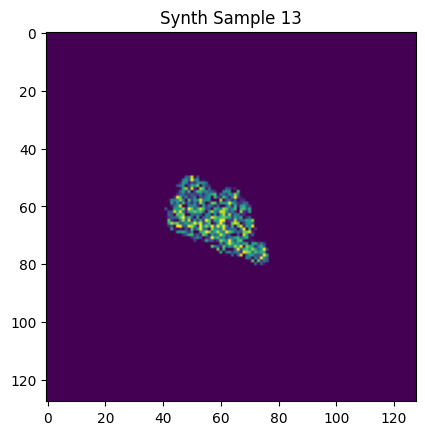

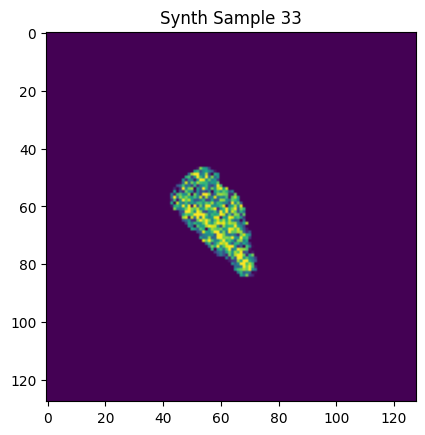

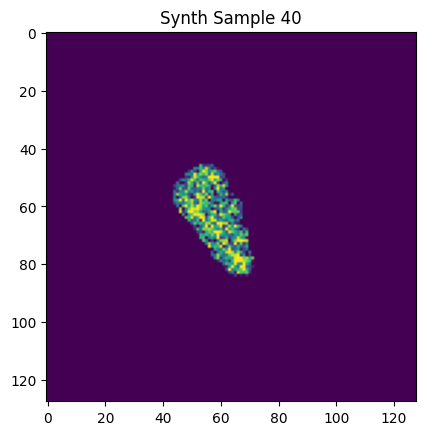

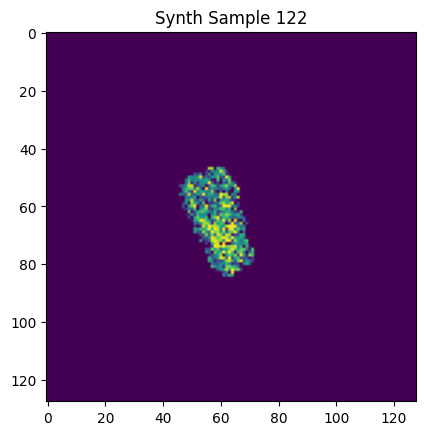

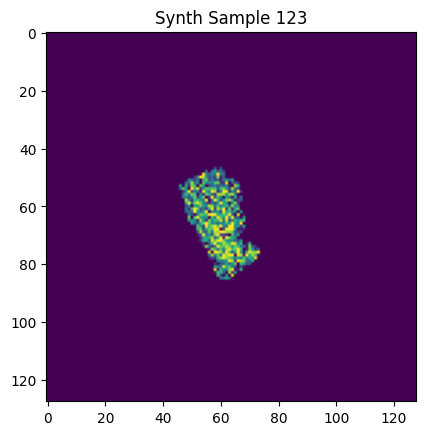

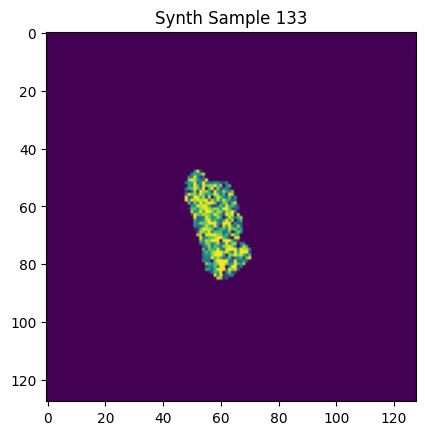

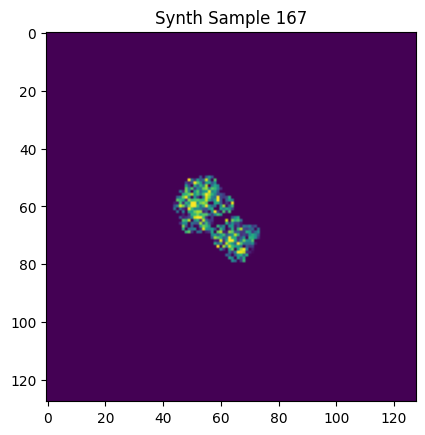

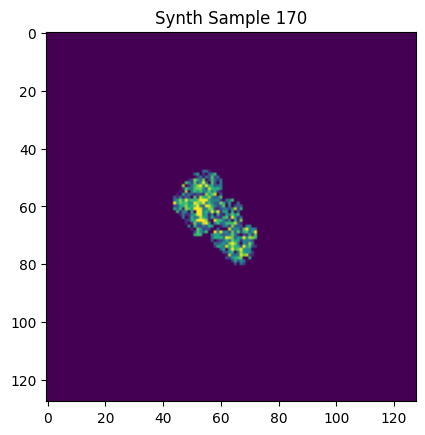

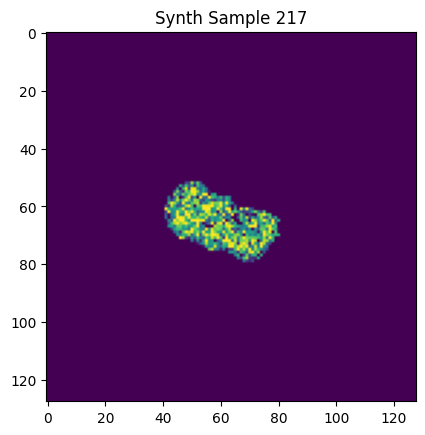

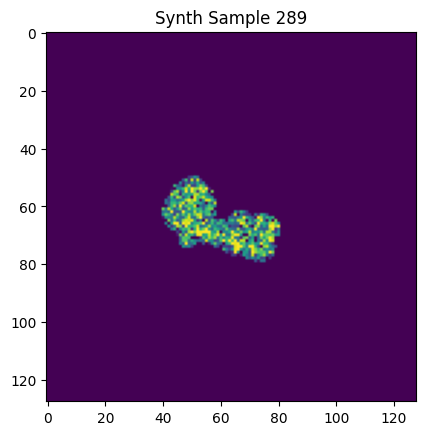

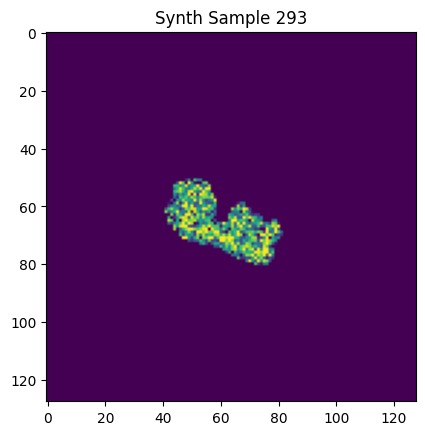

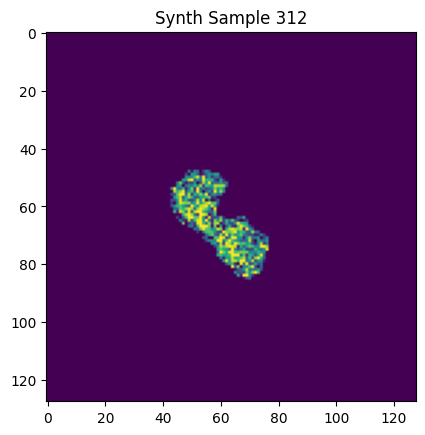

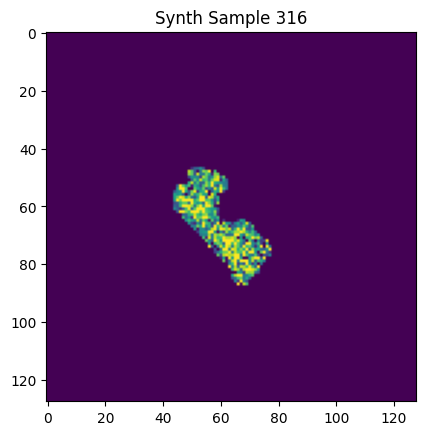

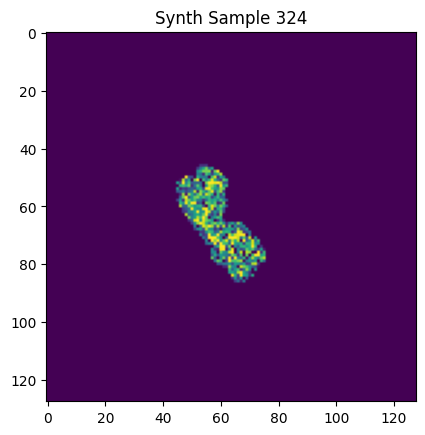

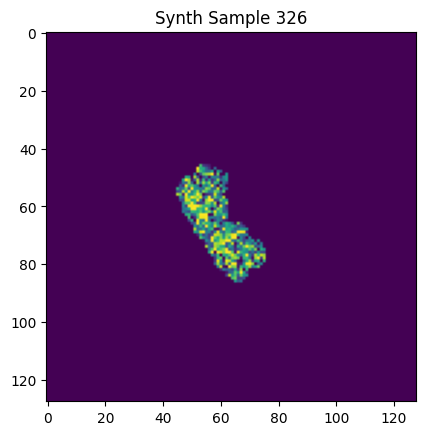

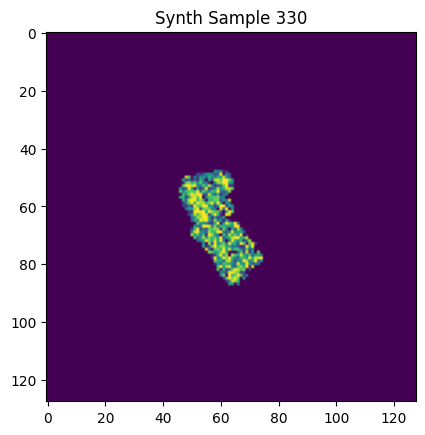

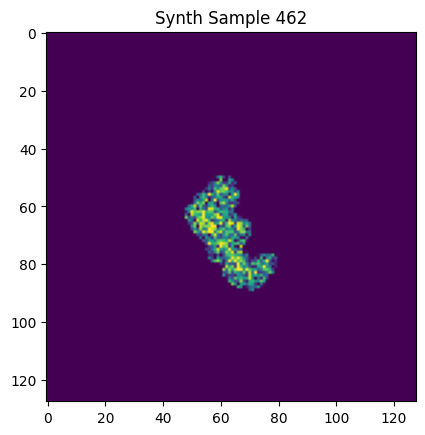

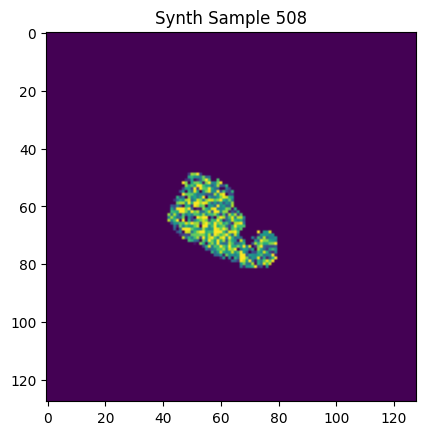

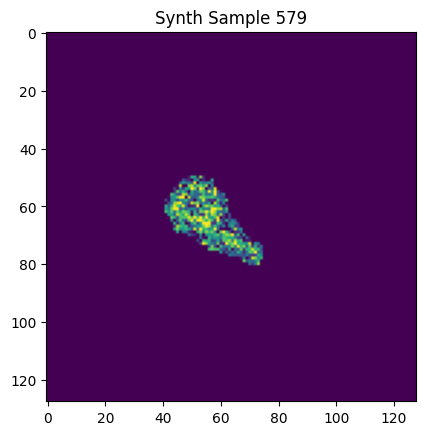

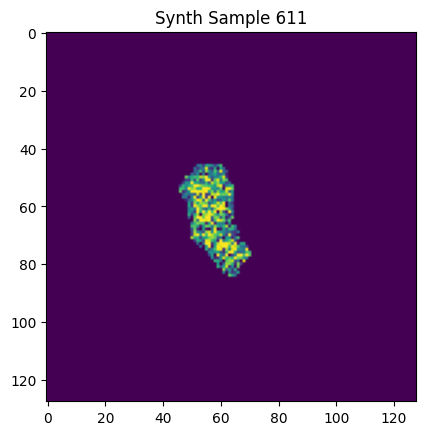

In [17]:
for i in np.sort(np.random.choice(700, 20, replace = False)):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.imshow(train_ds[i][0][0], vmin = 0, vmax = 1)
    ax.set_title(f"Synth Sample {i}")
    plt.show()

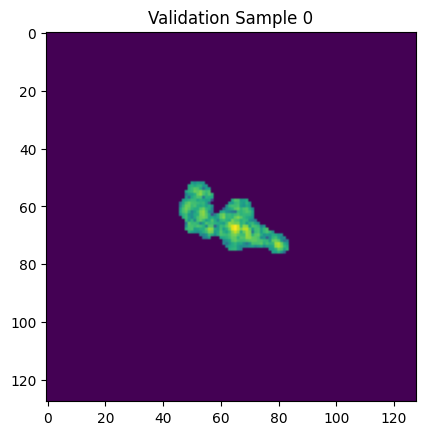

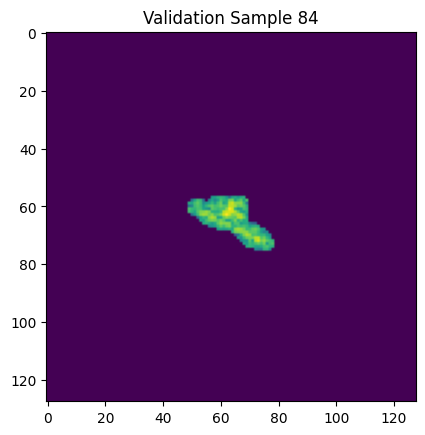

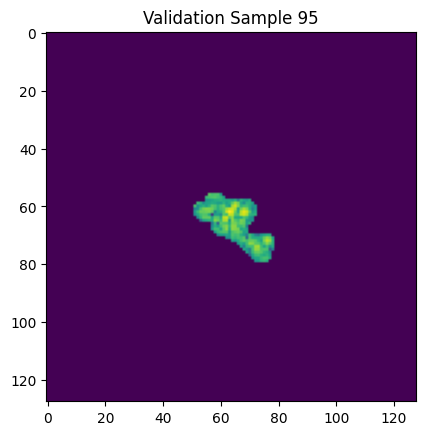

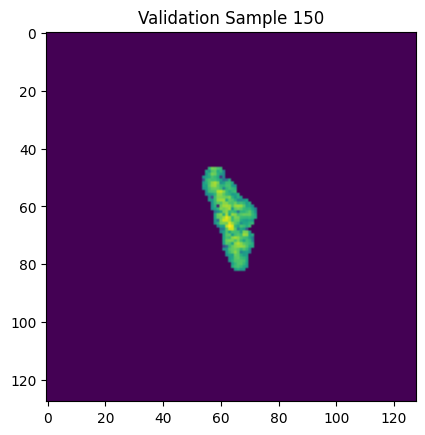

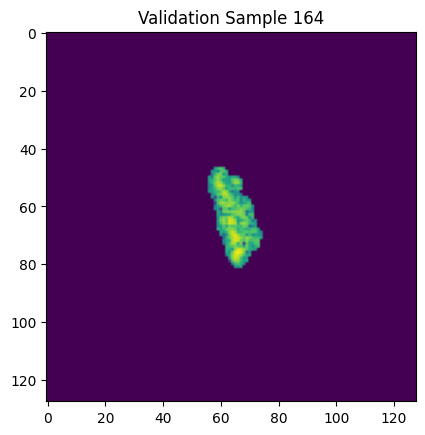

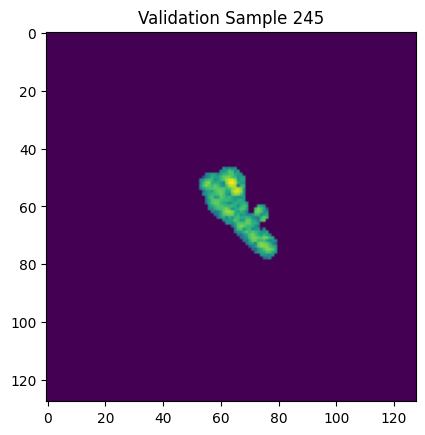

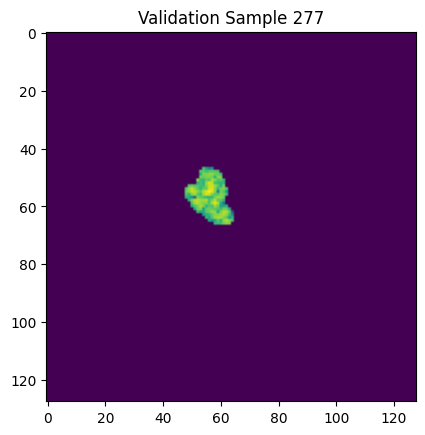

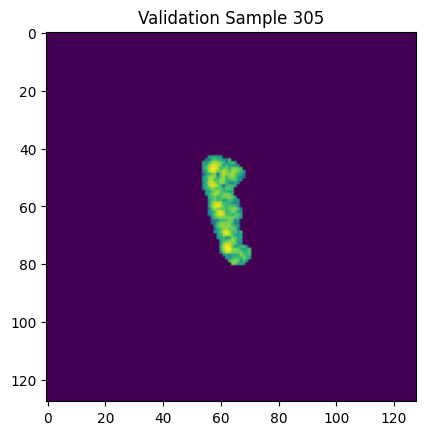

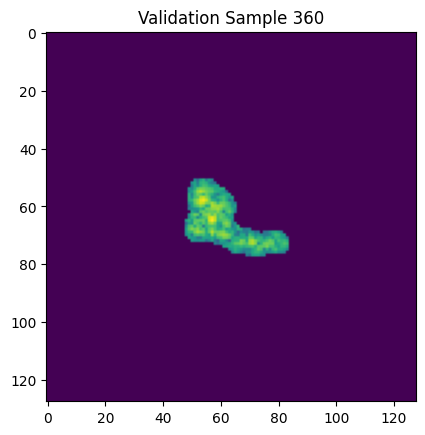

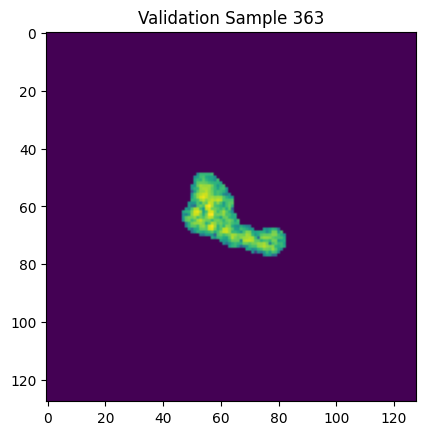

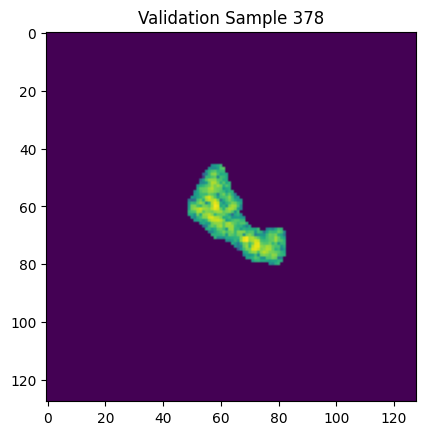

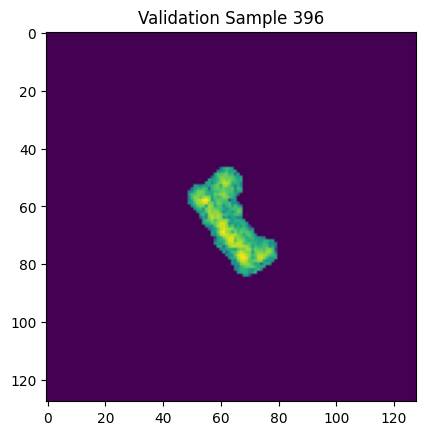

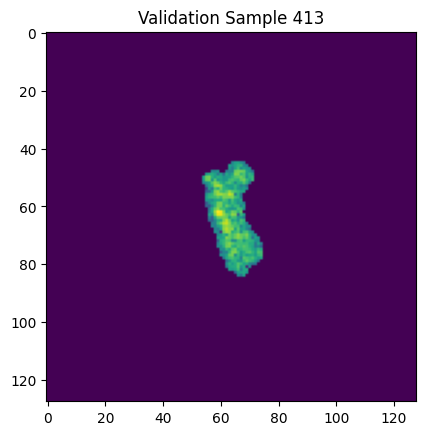

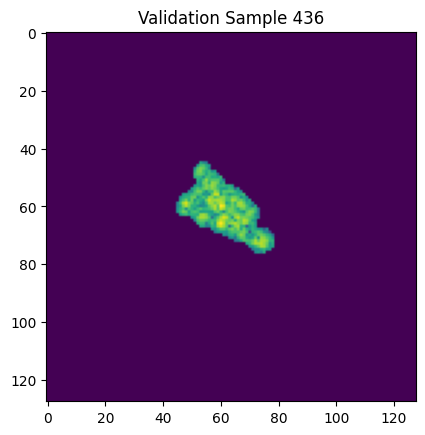

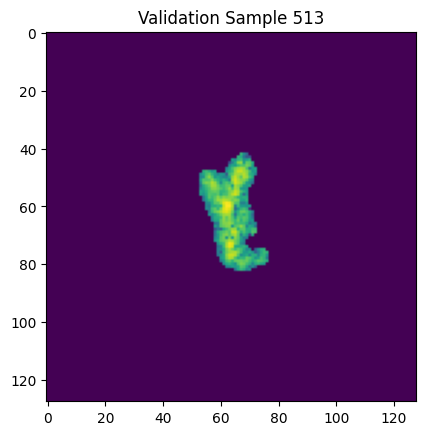

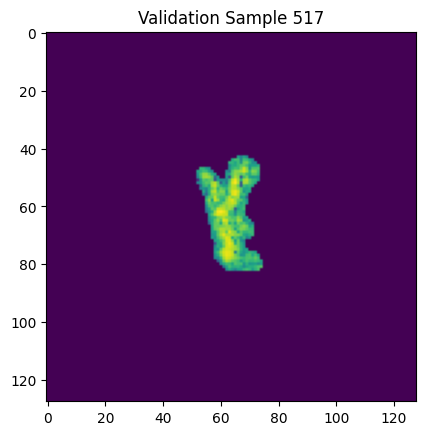

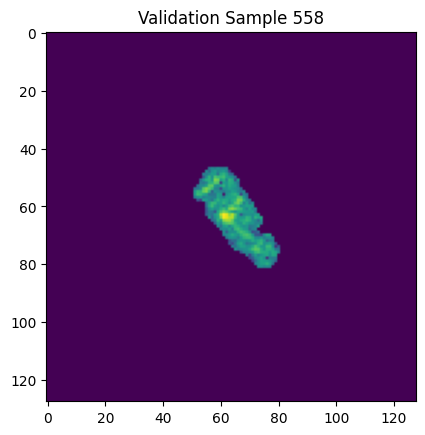

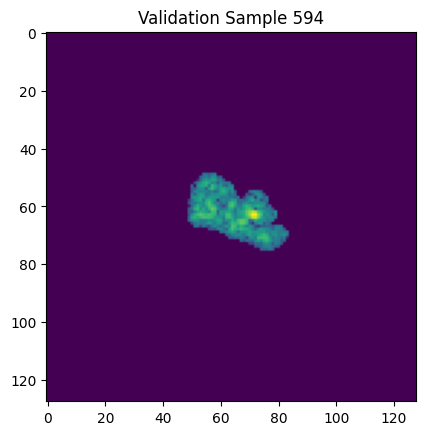

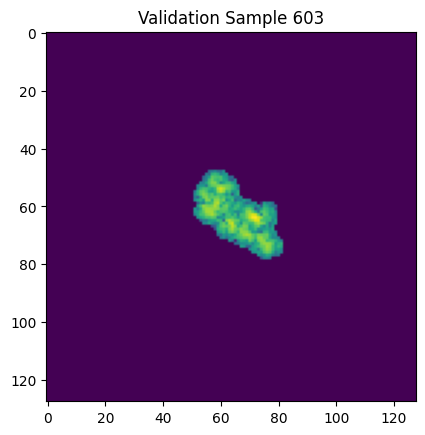

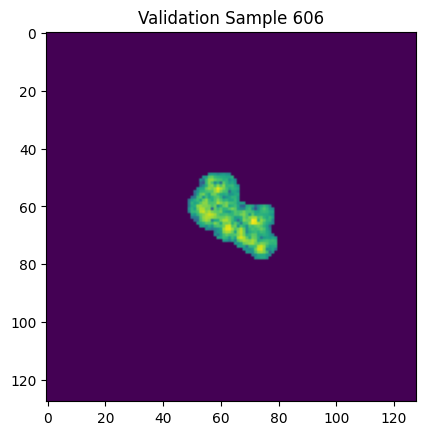

In [18]:
for i in np.sort(np.random.choice(647, 20, replace = False)):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.imshow(valid_ds[i][0][0], vmin = 0, vmax = 1)
    ax.set_title(f"Validation Sample {i}")
    plt.show()

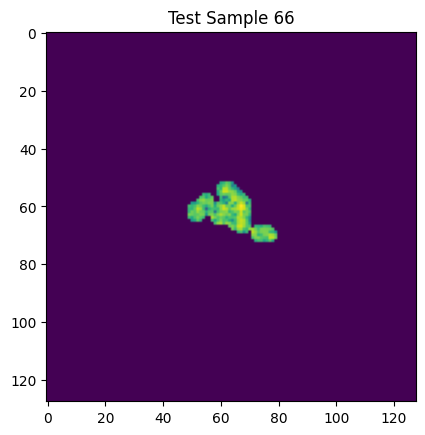

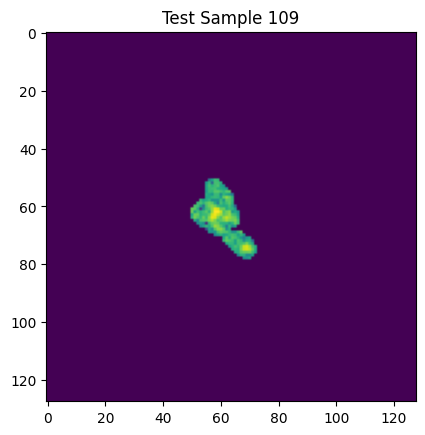

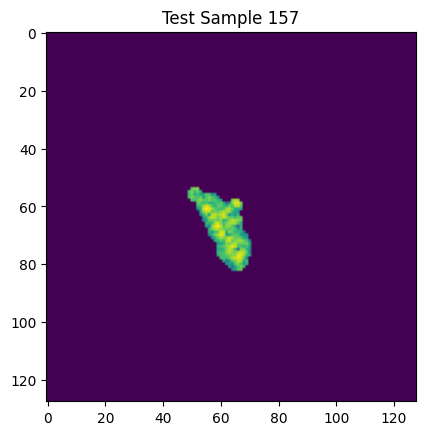

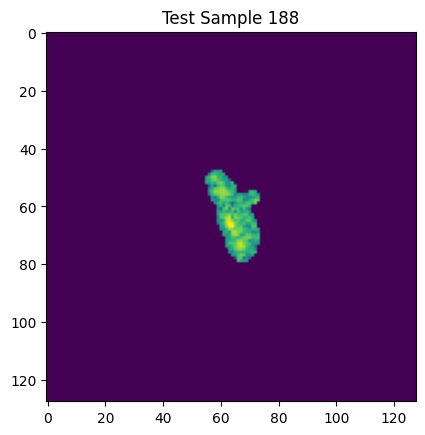

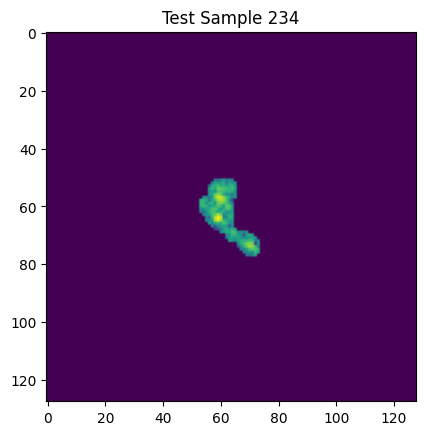

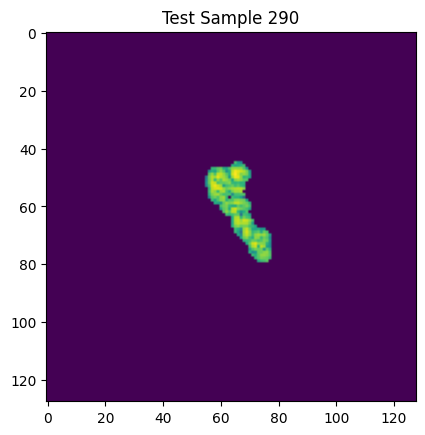

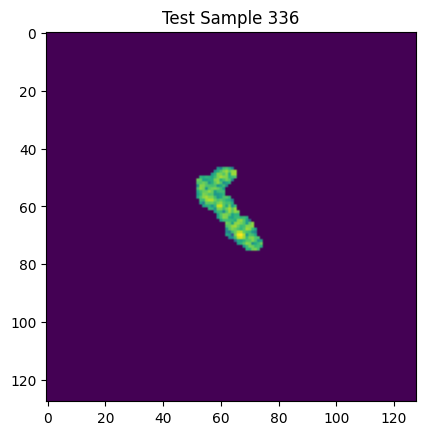

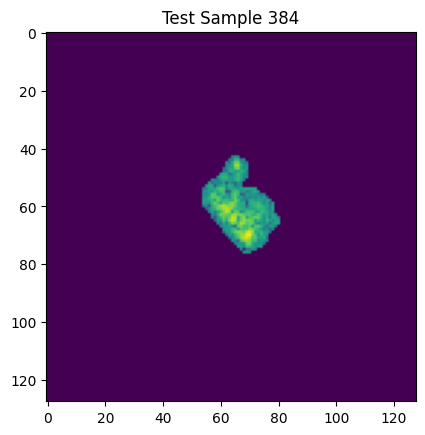

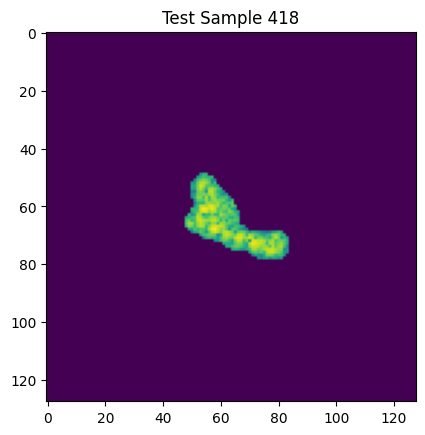

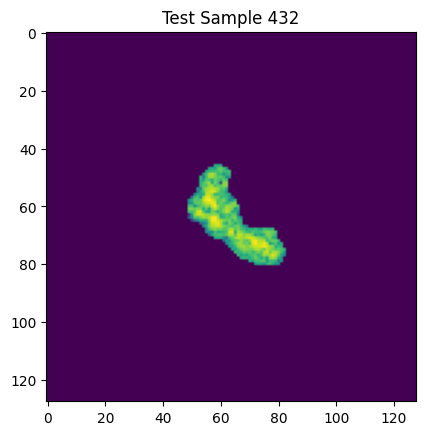

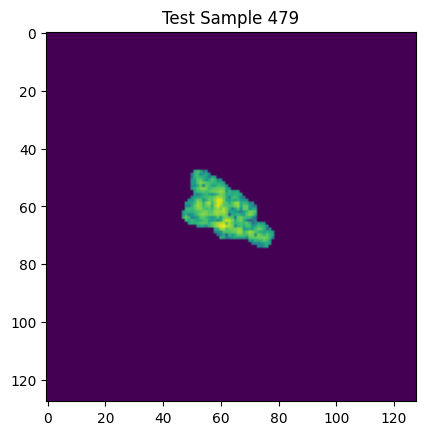

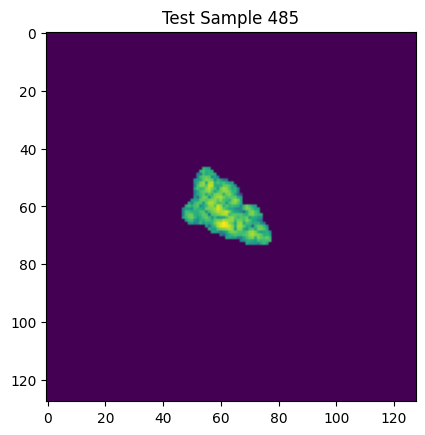

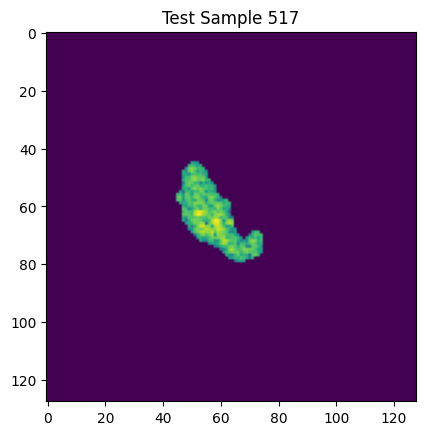

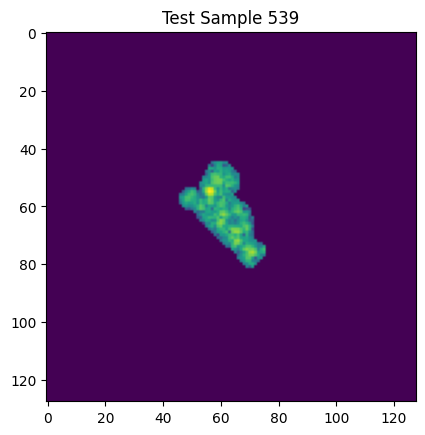

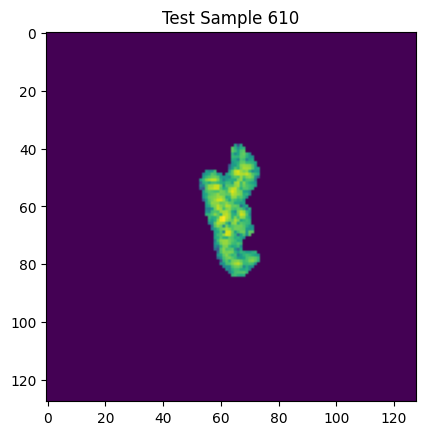

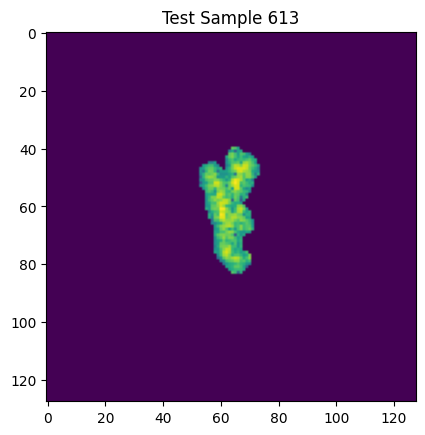

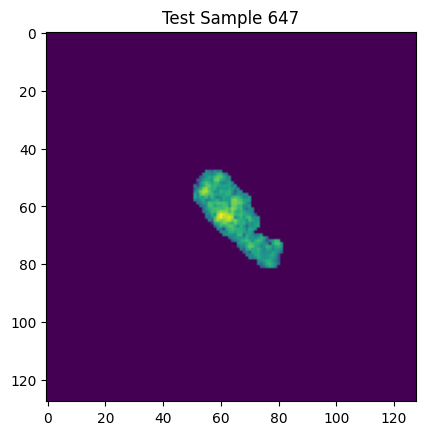

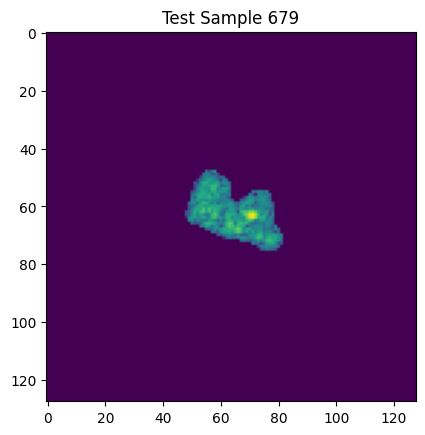

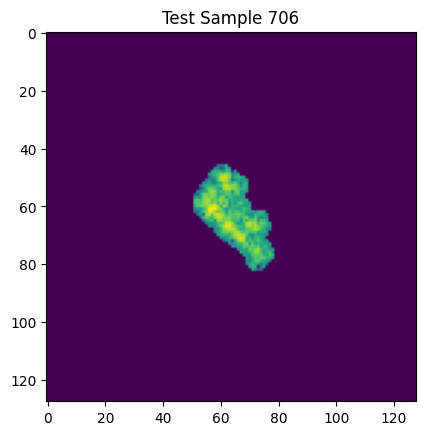

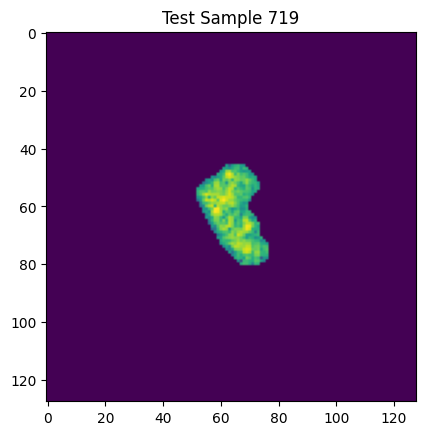

In [19]:
for i in np.sort(np.random.choice(730, 20, replace = False)):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.imshow(test_ds[i][0][0], vmin = 0, vmax = 1)
    ax.set_title(f"Test Sample {i}")
    plt.show()

In [20]:
model_check = LPDResNet18(num_classes=10, logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32})
pool_param_count = sum(p.numel() for n, p in model_check.named_parameters() if "component_selection" in n)
total_param_count = sum(p.numel() for p in model_check.parameters())
print(f"{pool_param_count} ({100*pool_param_count/total_param_count:.2f}% of total)")

210656 (1.85% of total)


In [21]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    # --- CHANGED: LPD-ResNet18 instead of models.resnet18 ---
    # Dropout head is already built into LPDResNet18 (dropout_p=0.4 default),
    # so no separate model.fc = nn.Sequential(...) override needed here.
    model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32})
 
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
 
    # --- CHANGED: split params so LPD's internal phase-selection logits
    # (component_selection submodules) get weight_decay=0, everything
    # else (backbone convs/BN/fc) keeps your usual 2e-4. See paper
    # Appendix A4.4.1 for why: weight decay on the selection logits
    # pushes them toward equal magnitude, which destabilizes the hard
    # phase selection the shift-invariance guarantee depends on.
    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
 
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
 
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
 
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            # --- CHANGED: conv1 now lives under model.core.conv1,
            # since LPDResNet18 wraps a torchvision ResNet as self.core
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000035
train Loss: 2.0721667 Acc: 0.2142857
val Loss: 7.4898546 Acc: 0.0757342
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.4901440 Acc: 0.4542857
val Loss: 8.0236956 Acc: 0.0726430
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.0261889 Acc: 0.5914286
val Loss: 4.5508627 Acc: 0.1112828
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.7491564 Acc: 0.7185714
val Loss: 5.9741020 Acc: 0.1035549
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.6018880 Acc: 0.7757143
val Loss: 4.7979077 Acc: 0.2102009
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.5213327 Acc: 0.8100000
val Loss: 5.0800991 Acc: 0.2442040
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.4460929 Acc: 0.8385714
val Loss: 6.0837569 Acc: 0.1576507
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.4185166 Acc: 0.8685714
val Loss: 3.5307901 Acc: 0.2380216
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.3277969 Acc: 0.8914286
val Loss: 3.6779635 Acc: 0.2117465
Epoch 8 LR: 0.0002985050
Epoc

In [11]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32})
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100 * test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
Test Accuracy: 32.6027
Evaluating Run 1: Seed 42
Test Accuracy: 34.6575
Evaluating Run 2: Seed 100
Test Accuracy: 30.4110
Evaluating Run 3: Seed 123
Test Accuracy: 32.6027
Evaluating Run 4: Seed 666
Test Accuracy: 39.3151
Evaluating Run 5: Seed 777
Test Accuracy: 34.3836
Evaluating Run 6: Seed 849
Test Accuracy: 31.9178
Evaluating Run 7: Seed 1000
Test Accuracy: 39.8630
Evaluating Run 8: Seed 1111
Test Accuracy: 33.8356
Evaluating Run 9: Seed 1234
Test Accuracy: 31.7808
Min: 30.4110
Max: 39.8630
Avg, Std: 34.1370, 2.9848


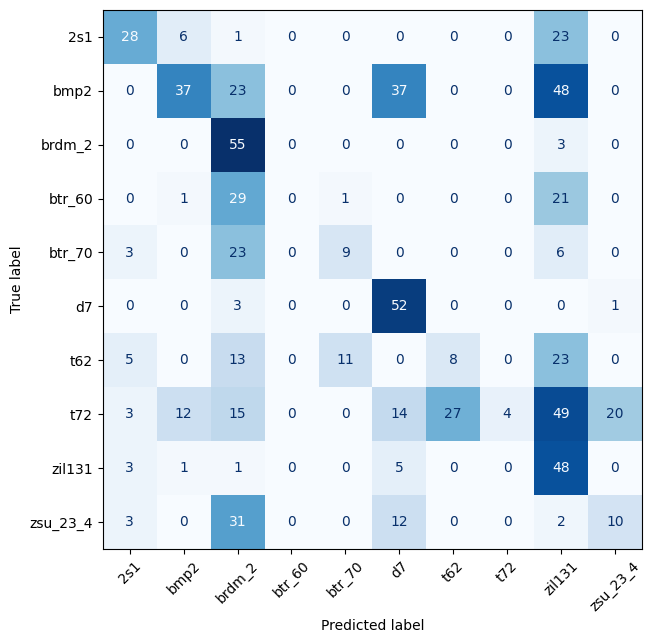

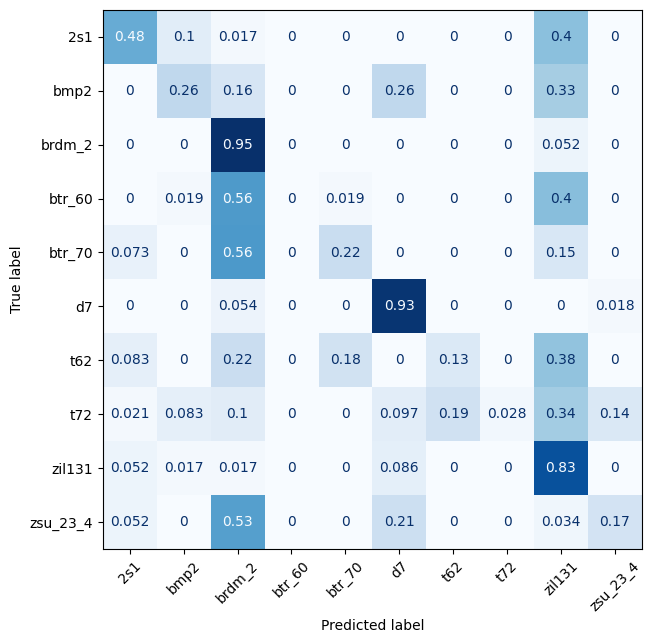

In [7]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 777
device = torch.device("cuda:0")
new_model = LPDResNet18(
    num_classes=len(train_ds.class_to_idx),
    logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))
new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

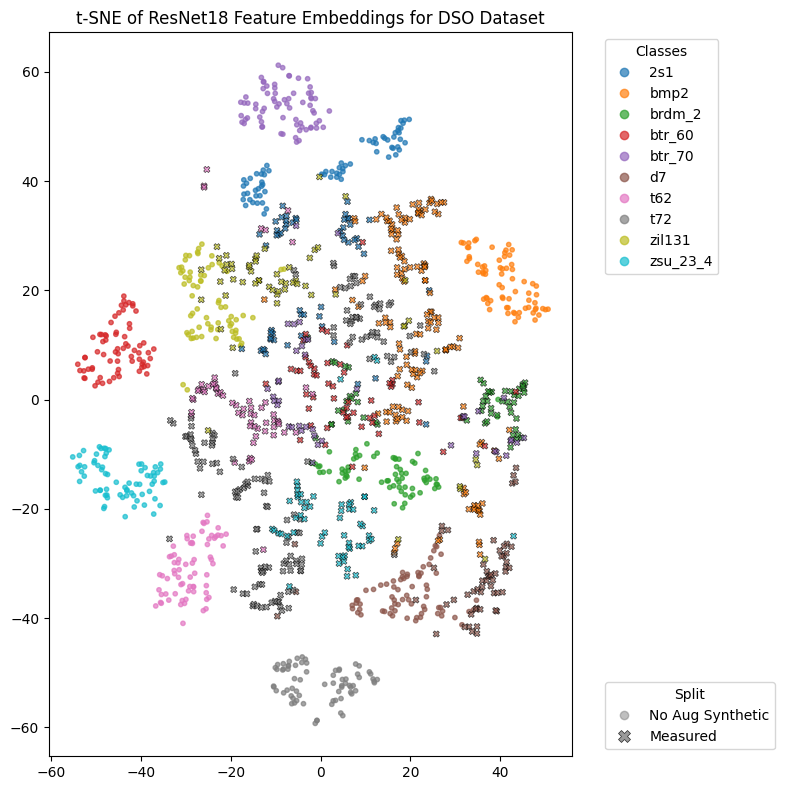

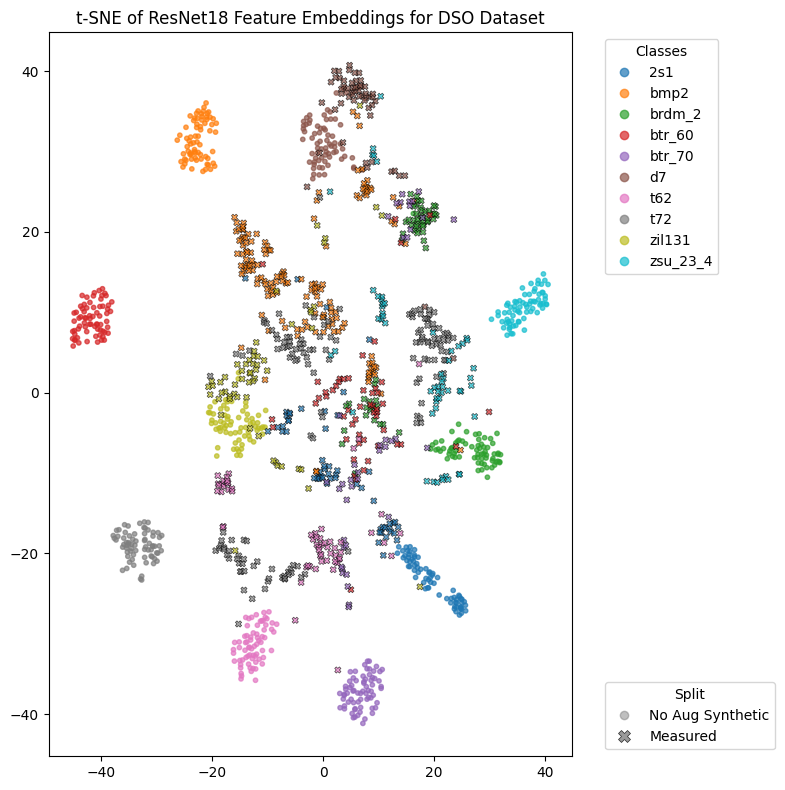

[2026-07-14 08:13:17.038] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


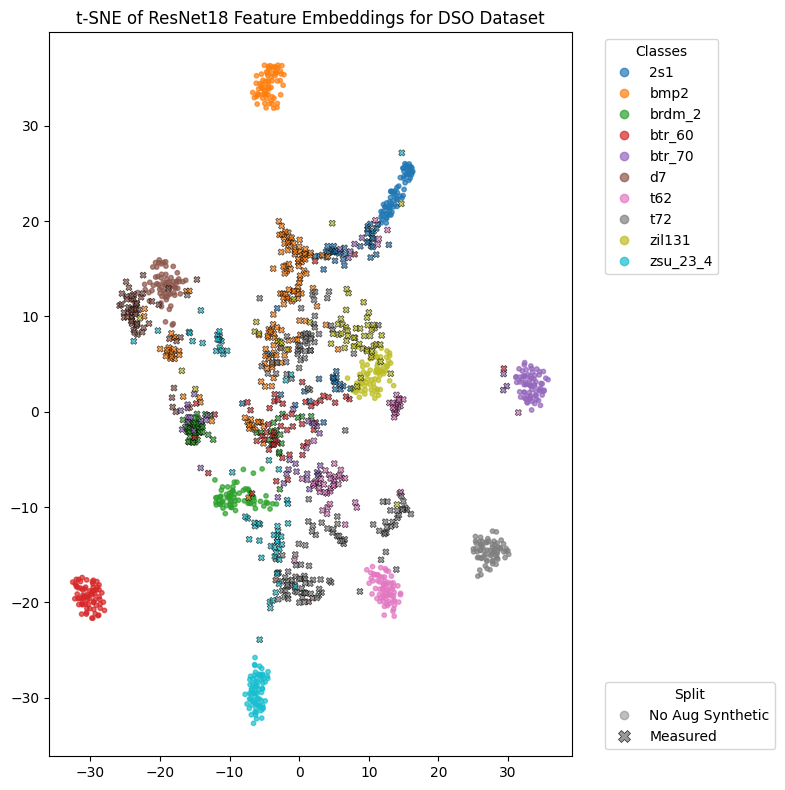

[2026-07-14 08:13:17.604] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-07-14 08:13:17.604] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


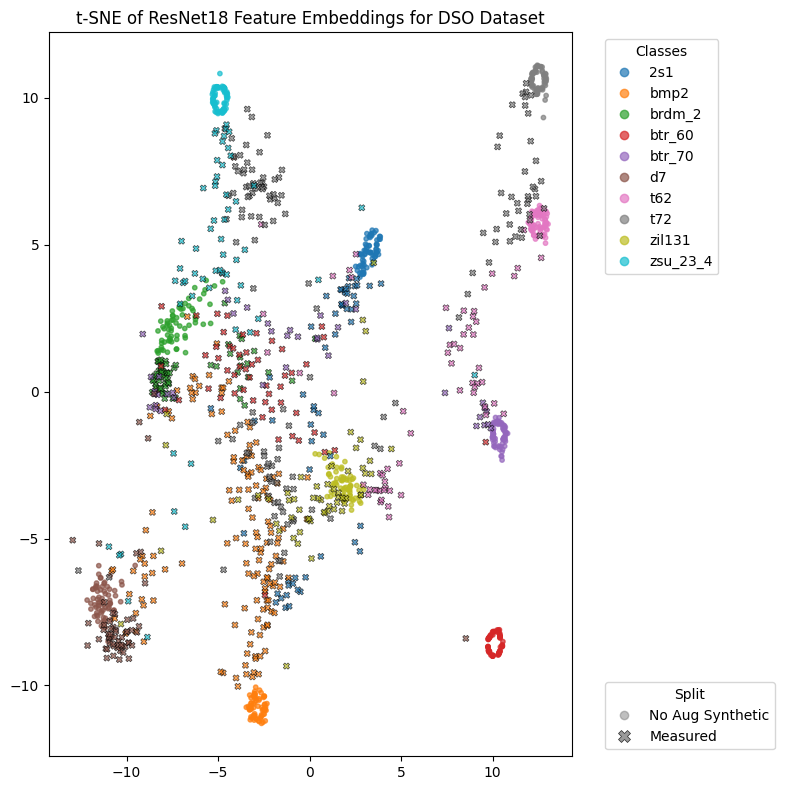

In [8]:
train_plot_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(no_aug_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)
test_plot_ds = test_ds
combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_dataloader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 777
device = torch.device("cuda:0")
new_model = LPDResNet18(
    num_classes=len(train_ds.class_to_idx),
    logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))
new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.core.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), dtype=torch.float, device=device)  # Adjust the second dimension as needed
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in combined_dataloader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)

        bs = feats.size(0)
        features_tensor[idx:idx+bs] = feats
        labels_tensor[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving to CPU

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 30, 50, 100]:

    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
    )

    features_2d = tsne.fit_transform(_features)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_plot_ds), 0],
        features_2d[:len(train_plot_ds), 1],
        c=_labels[:len(train_plot_ds)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d[len(train_plot_ds):, 0],
        features_2d[len(train_plot_ds):, 1],
        c=_labels[len(train_plot_ds):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title("t-SNE of ResNet18 Feature Embeddings for DSO Dataset")
    plt.tight_layout()
    plt.show()

[2026-07-14 08:13:34.467] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 25


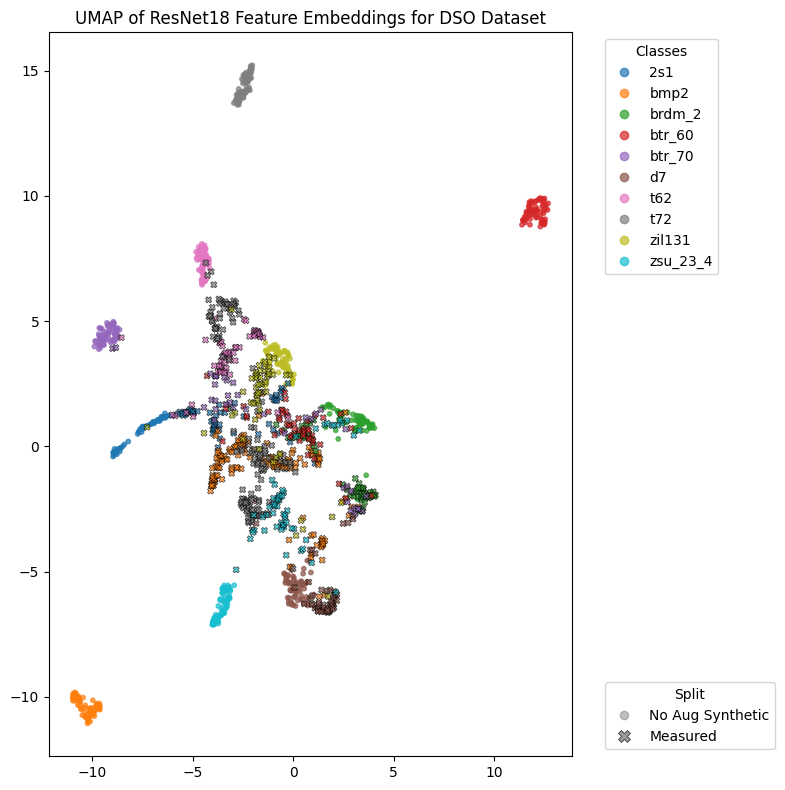

[2026-07-14 08:13:34.879] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 50


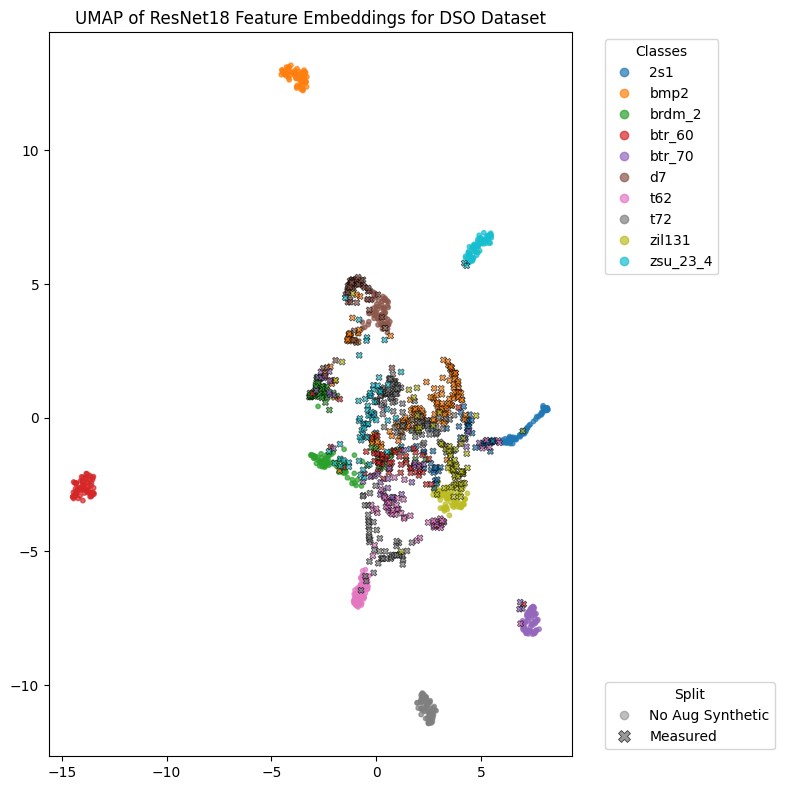

[2026-07-14 08:13:35.053] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 100


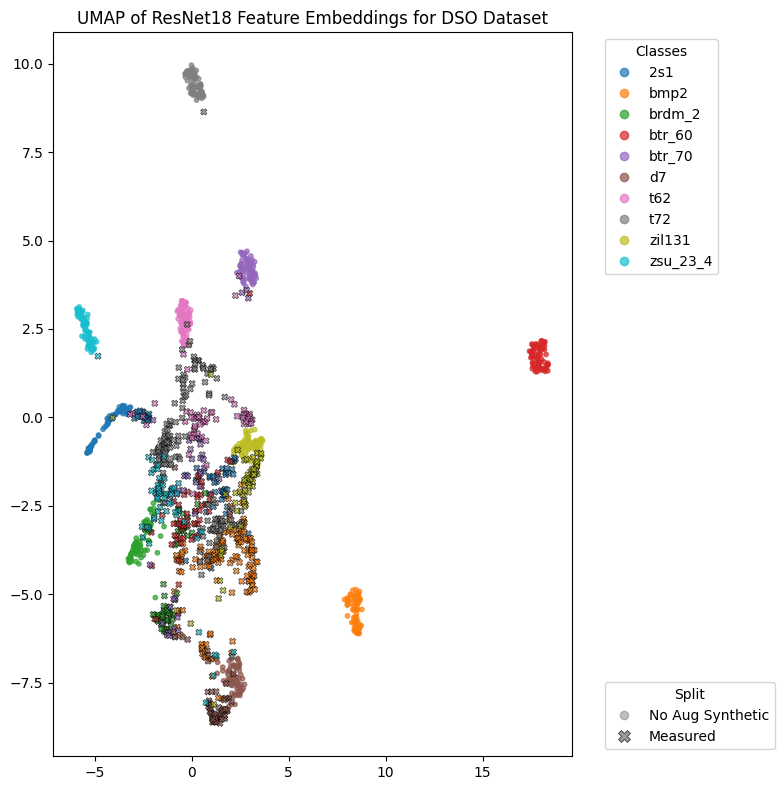

[2026-07-14 08:13:35.229] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')
UMAP n_neighbours = 200


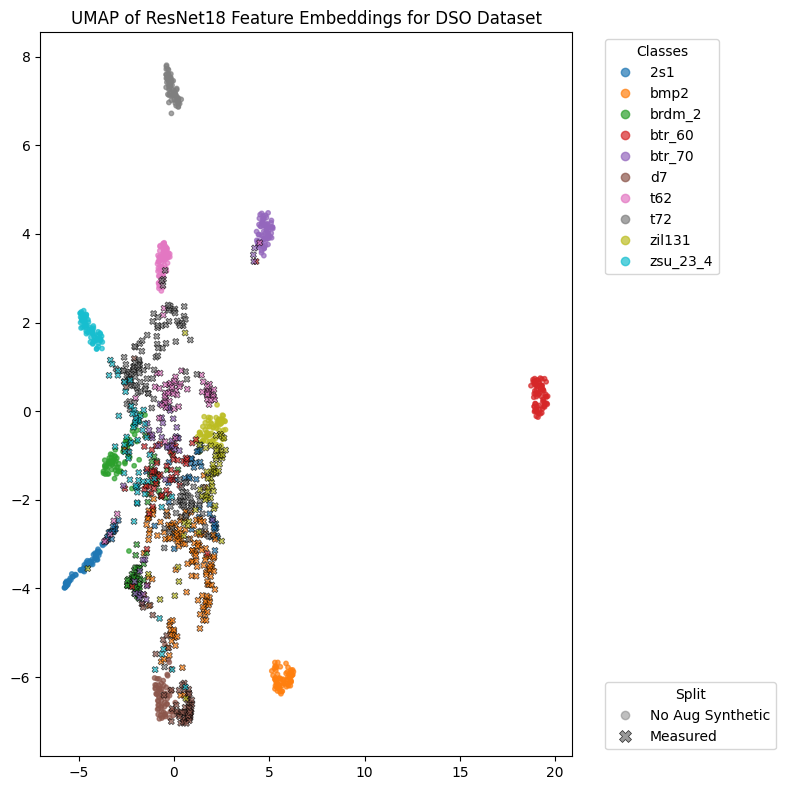

In [9]:
train_plot_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(no_aug_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)
test_plot_ds = test_ds
combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_dataloader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 777
device = torch.device("cuda:0")
new_model = LPDResNet18(
    num_classes=len(train_ds.class_to_idx),
    logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}
)

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))
new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.core.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), dtype=torch.float, device=device)  # Adjust the second dimension as needed
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in combined_dataloader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)

        bs = feats.size(0)
        features_tensor[idx:idx+bs] = feats
        labels_tensor[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving to CPU

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [25, 50, 100, 200]:

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(_features)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)
    
    print(f"UMAP n_neighbours = {num}")

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=_labels[:len(train_plot_ds)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=_labels[len(train_plot_ds):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title("UMAP of ResNet18 Feature Embeddings for DSO Dataset")
    plt.tight_layout()
    plt.show()

In [12]:
no_aug_train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(no_aug_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)

gaussian_train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(gaussian_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)

seed = 777
set_seed(seed)
device = torch.device("cuda:0")

new_model = LPDResNet18(
    num_classes=len(train_ds.class_to_idx),
    logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}
)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))

new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.core.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

gaussian_train_loader = DataLoader(
    gaussian_train_ds, batch_size=32, 
    shuffle=False, num_workers=8, 
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
)

n_synth = len(gaussian_train_ds)
gaussian_synth_feats_gpu = torch.zeros((200 * n_synth, 512), dtype=torch.float, device=device)
gaussian_synth_labels_gpu = torch.zeros(200 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(200), desc="Extracting features for Gaussian Augmented Synthetic"):
    with torch.no_grad():
        for inputs, targets in gaussian_train_loader:
            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)

            bs = feats.size(0)
            gaussian_synth_feats_gpu[idx:idx+bs] = feats
            gaussian_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving to CPU

gaussian_synth_feats = gaussian_synth_feats_gpu.cpu().numpy()
gaussian_synth_labels = gaussian_synth_labels_gpu.cpu().numpy()

no_aug_train_loader = DataLoader(
    no_aug_train_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(no_aug_train_ds)
no_aug_synth_feats_gpu = torch.zeros((n_no_aug_synth, 512), dtype=torch.float, device=device)
no_aug_synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in no_aug_train_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)

        bs = feats.size(0)
        no_aug_synth_feats_gpu[idx:idx+bs] = feats
        no_aug_synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving to CPU

no_aug_synth_feats = no_aug_synth_feats_gpu.cpu().numpy()
no_aug_synth_labels = no_aug_synth_labels_gpu.cpu().numpy()

meas_loader = DataLoader(
    test_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
)

n_meas = len(test_ds)
meas_feats_gpu = torch.zeros((n_meas, 512), dtype=torch.float, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in meas_loader:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)

        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs] = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving to CPU

meas_feats = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

del gaussian_synth_feats_gpu, gaussian_synth_labels_gpu, no_aug_synth_feats_gpu, no_aug_synth_labels_gpu, meas_feats_gpu, meas_labels_gpu
torch.cuda.empty_cache()

Extracting features for Gaussian Augmented Synthetic: 100%|███████████████████████████| 200/200 [02:30<00:00,  1.33it/s]


[2026-07-14 08:16:32.238] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
UMAP n_neighbours = 50


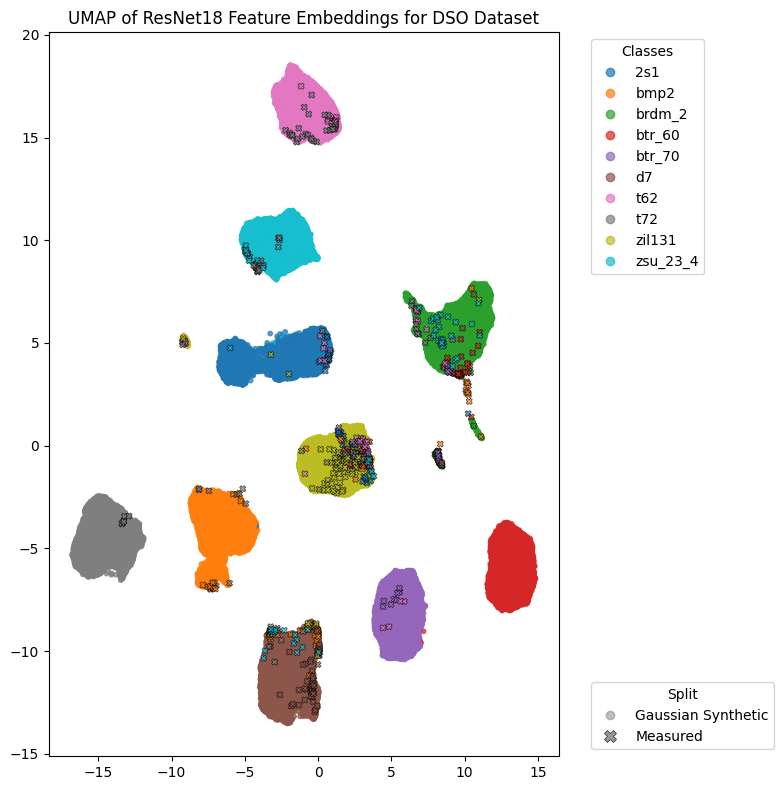

[2026-07-14 08:16:35.924] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:16:35.925] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
UMAP n_neighbours = 100


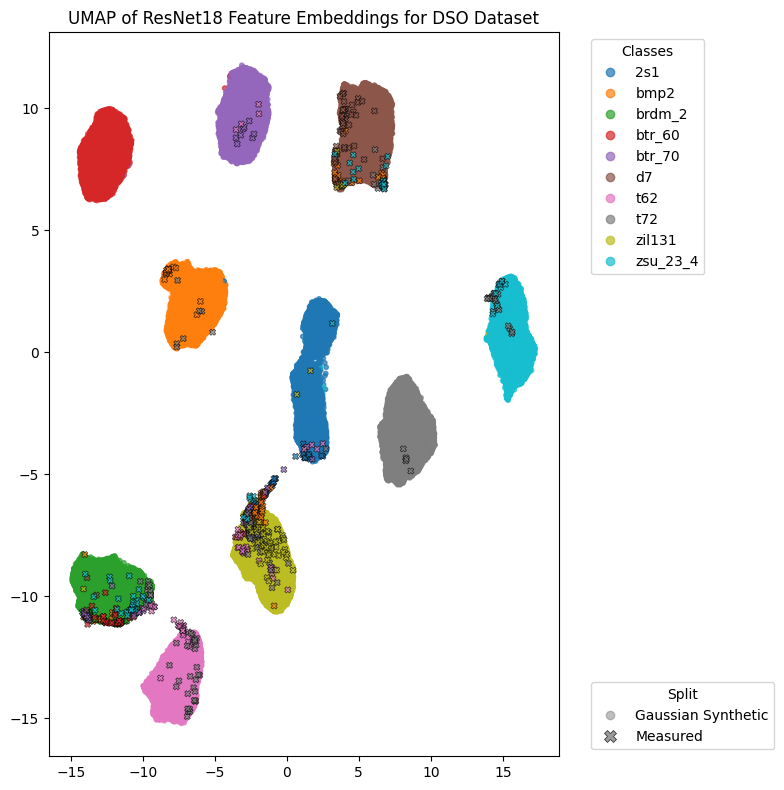

[2026-07-14 08:16:40.199] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:16:40.200] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:16:40.200] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 200


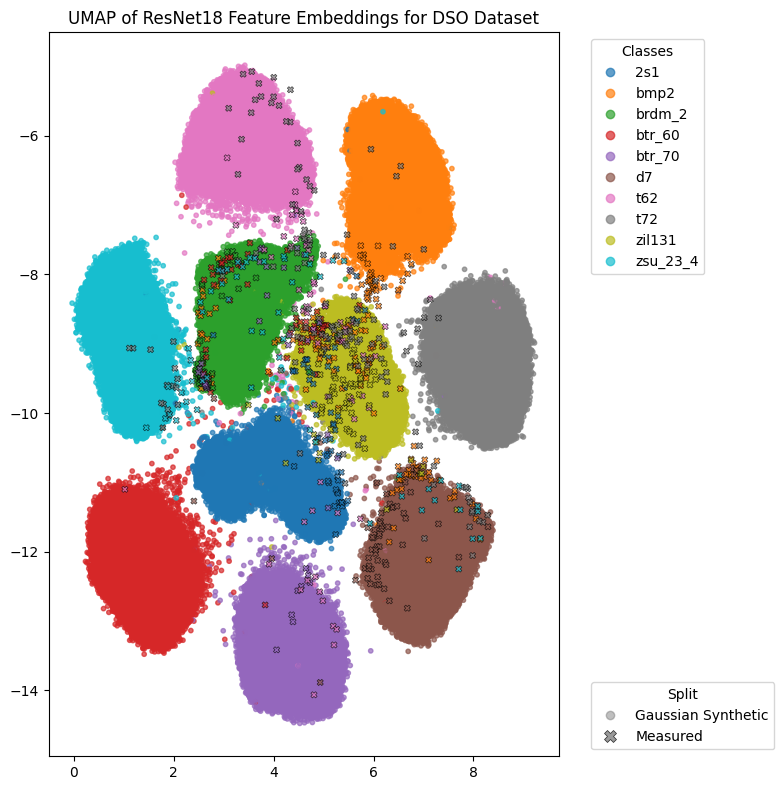

[2026-07-14 08:16:43.990] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:16:43.991] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:16:43.991] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 250


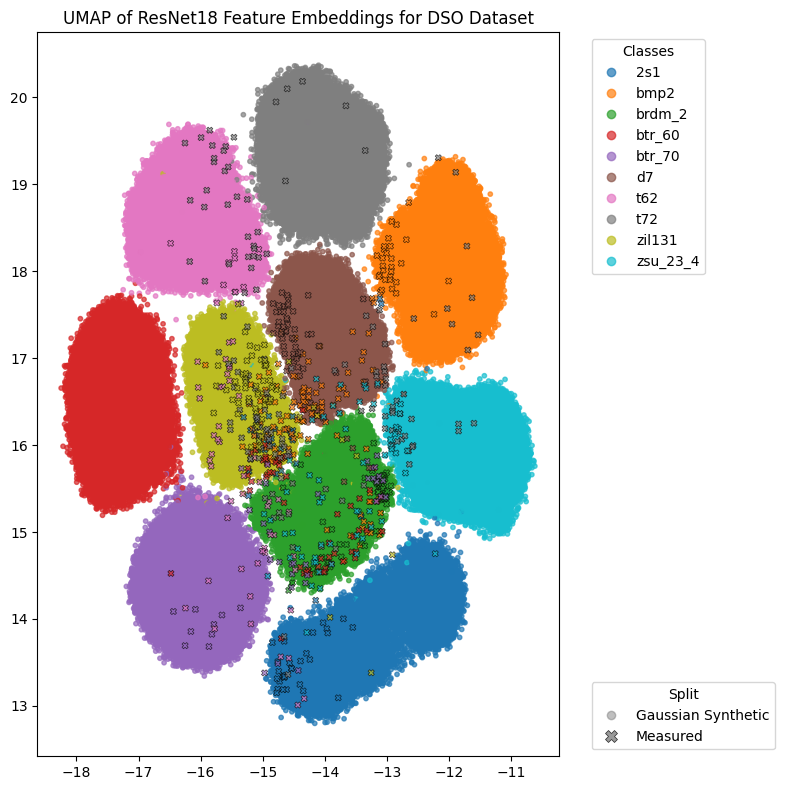

[2026-07-14 08:16:52.246] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:16:52.248] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:16:52.248] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 300


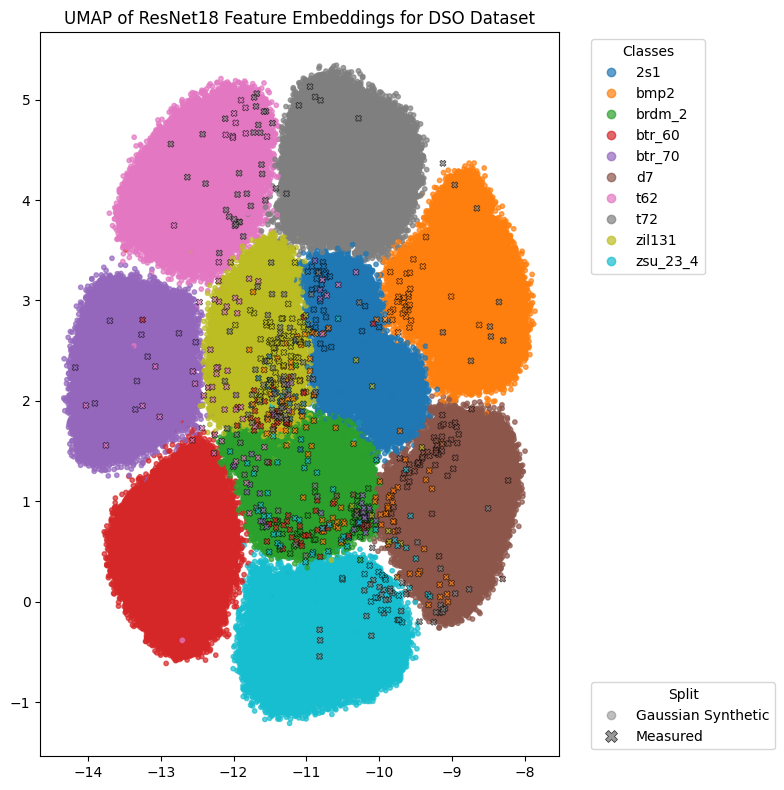

In [11]:
combined_feats = np.concatenate([gaussian_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([gaussian_synth_labels, meas_labels], axis=0)

for num in [50, 100, 200, 250, 300]:
    
    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(combined_feats)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_plot_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)
    
    print(f"UMAP n_neighbours = {num}")

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(gaussian_synth_feats), 0],
        features_2d_umap[:len(gaussian_synth_feats), 1],
        c=combined_labels[:len(gaussian_synth_feats)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(gaussian_synth_feats):, 0],
        features_2d_umap[len(gaussian_synth_feats):, 1],
        c=combined_labels[len(gaussian_synth_feats):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for DSO Dataset")
    plt.tight_layout()
    plt.show()

[2026-07-14 08:28:39.562] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
UMAP n_neighbours = 50


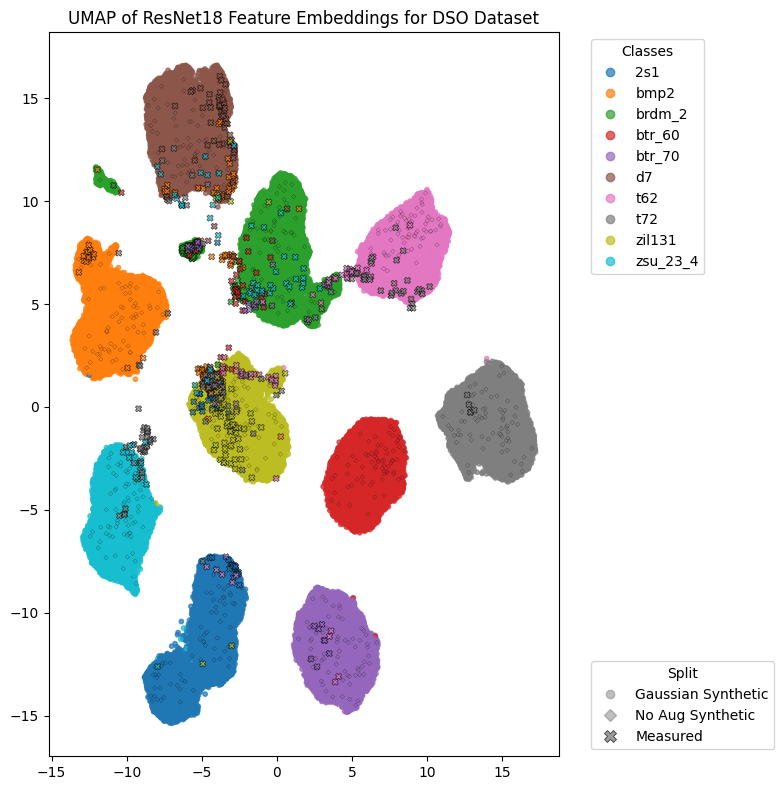

[2026-07-14 08:28:43.322] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:28:43.323] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
UMAP n_neighbours = 100


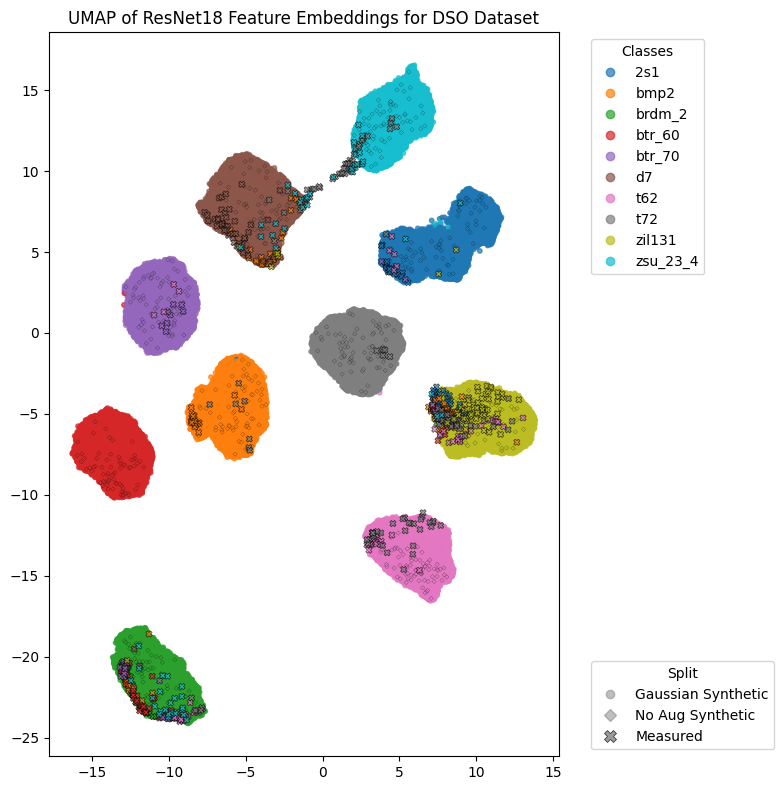

[2026-07-14 08:28:47.629] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:28:47.630] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:28:47.630] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 200


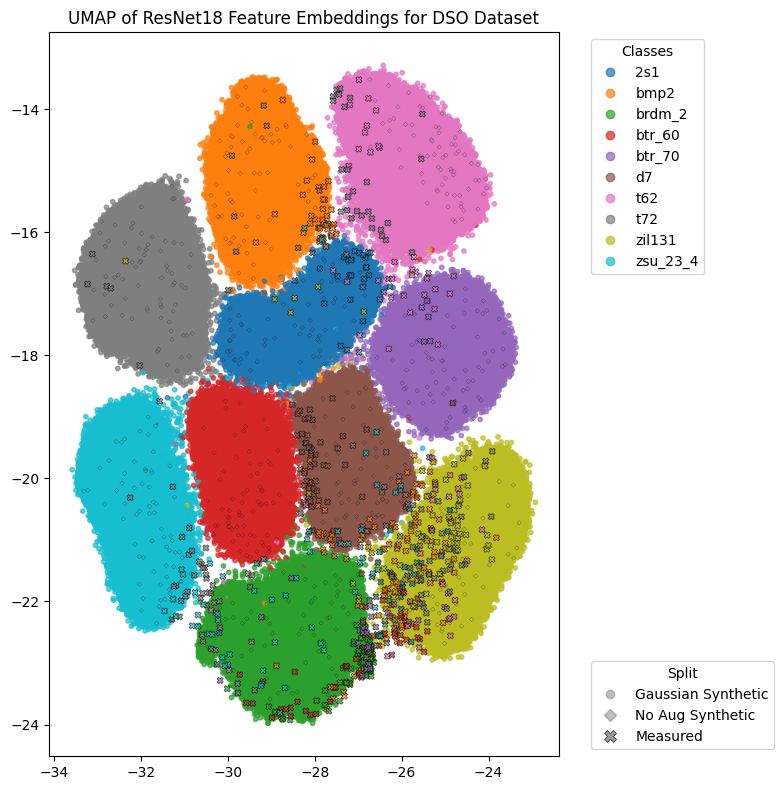

[2026-07-14 08:28:54.410] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:28:54.412] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:28:54.412] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 250


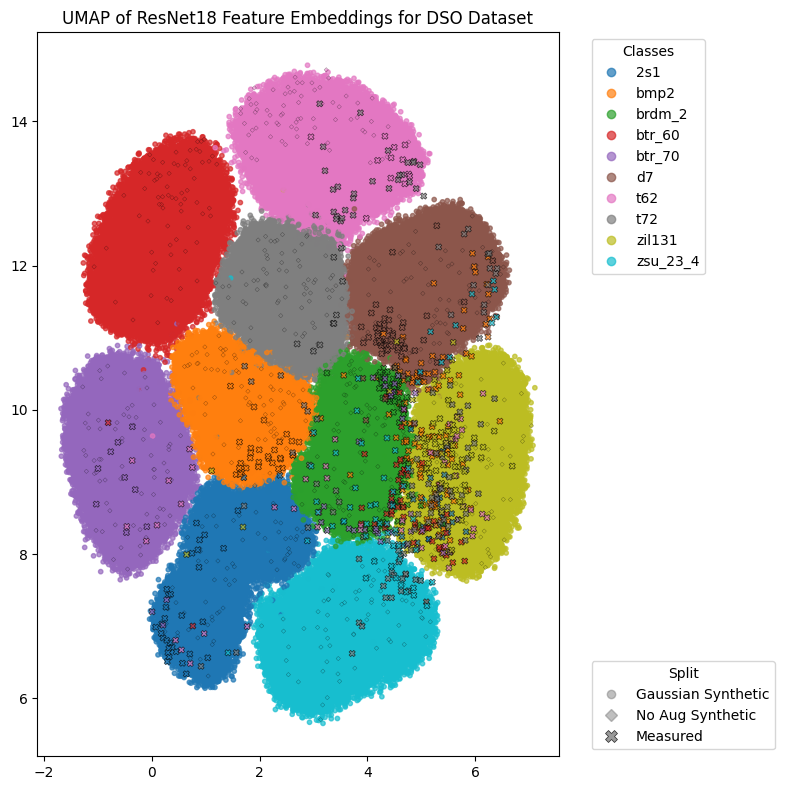

[2026-07-14 08:28:59.986] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-07-14 08:28:59.987] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 08:28:59.987] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree
UMAP n_neighbours = 300


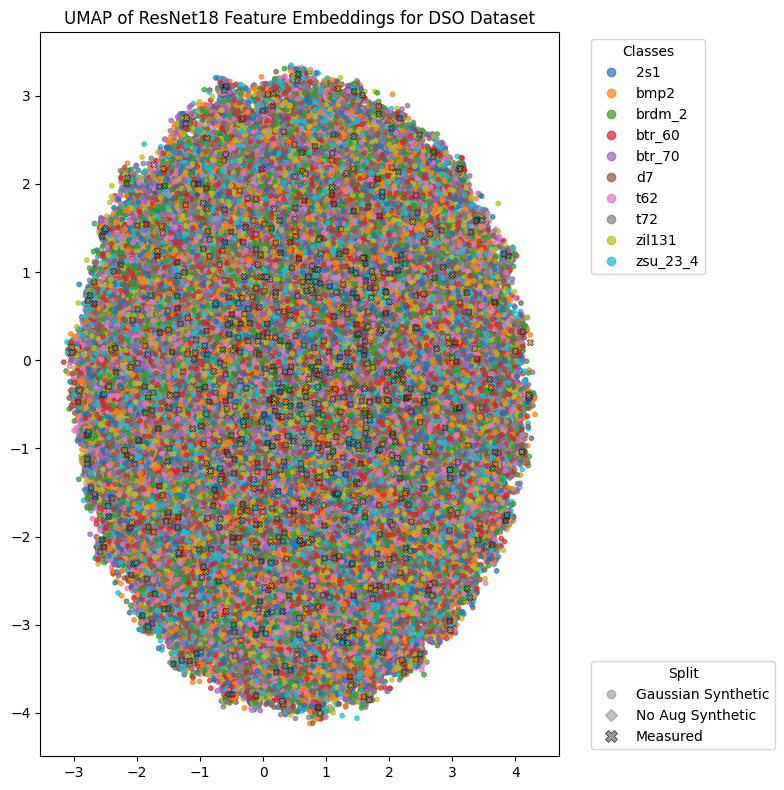

In [15]:
combined_feats = np.concatenate([gaussian_synth_feats, no_aug_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([gaussian_synth_labels, no_aug_synth_labels, meas_labels], axis=0)

for num in [50, 100, 200, 250, 300]:
    
    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.5,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(combined_feats)

    # Get class names from the dataset
    class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

    n_classes = len(class_names)
    
    print(f"UMAP n_neighbours = {num}")

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(gaussian_synth_feats), 0],
        features_2d_umap[:len(gaussian_synth_feats), 1],
        c=combined_labels[:len(gaussian_synth_feats)],
        cmap="tab10",
        s=10,
        alpha=0.7,
        marker = "o",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(gaussian_synth_feats):len(gaussian_synth_feats)+len(no_aug_synth_feats), 0],
        features_2d_umap[len(gaussian_synth_feats):len(gaussian_synth_feats)+len(no_aug_synth_feats), 1],
        c=combined_labels[len(gaussian_synth_feats):len(gaussian_synth_feats)+len(no_aug_synth_feats)],
        cmap="tab10",
        s=5,
        alpha=0.5,
        linewidths=0.25,
        edgecolors="k",
        marker = "D",
        vmin=0, vmax=n_classes - 1
    )

    plt.scatter(
        features_2d_umap[len(gaussian_synth_feats)+len(no_aug_synth_feats):, 0],
        features_2d_umap[len(gaussian_synth_feats)+len(no_aug_synth_feats):, 1],
        c=combined_labels[len(gaussian_synth_feats)+len(no_aug_synth_feats):],
        cmap="tab10",
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k",
        vmin=0, vmax=n_classes - 1
    )

    class_legend = plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        title="Classes",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    fig.add_artist(class_legend)  # keep it when adding the second legend

    # Marker legend for train vs test
    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="Gaussian Synthetic"),
        Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for DSO Dataset")
    plt.tight_layout()
    plt.show()

In [16]:
train_plot_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(no_aug_zhao_target_synth_ds, {14, 15, 16}), list(range(10, 80, 1))), 
    exclude_label= 8)

device = torch.device("cuda:0")
seed = 777
set_seed(seed)

model = LPDResNet18(
    num_classes=len(train_ds.class_to_idx),
    logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}
)

# Load your trained weights
model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/gaussian/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))

synth_features, synth_labels, _ = _get_features_and_preds_from_LPD_model(model, train_plot_ds, device, seed)
meas_features, meas_labels, meas_preds = _get_features_and_preds_from_LPD_model(model, test_ds, device, seed)

In [17]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, meas_labels, synth_features, synth_labels, metric = "cosine"
)

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.036  0.143  0.214  (n=28)
bmp2        0.378  0.649  0.784  (n=37)
brdm_2      0.145  0.309  0.509  (n=55)
btr_70      0.333  0.667  0.667  (n=9)
d7          0.096  0.192  0.308  (n=52)
t62         0.250  0.375  0.500  (n=8)
t72         0.000  0.000  0.000  (n=4)
zil131      0.146  0.271  0.417  (n=48)
zsu_23_4    0.300  0.500  0.600  (n=10)
----------------------------
Overall     0.171  0.327  0.458  (n=251)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         1.000  4.000  6.000  (n=28)
bmp2        14.000  24.000  29.000  (n=37)
brdm_2      8.000  17.000  28.000  (n=55)
btr_70      3.000  6.000  6.000  (n=9)
d7          5.000  10.000  16.000  (n=52)
t62         2.000  3.000  4.000  (n=8)
t72         0.000  0.000  0.000  (n=4)
zil131      7.000  13.000  20.000  (n=48)
zsu_23_4    3.000  5.000  6.000  (n=10)
----------------------------
Overall     43.000  82.000  115.000  (n=251)


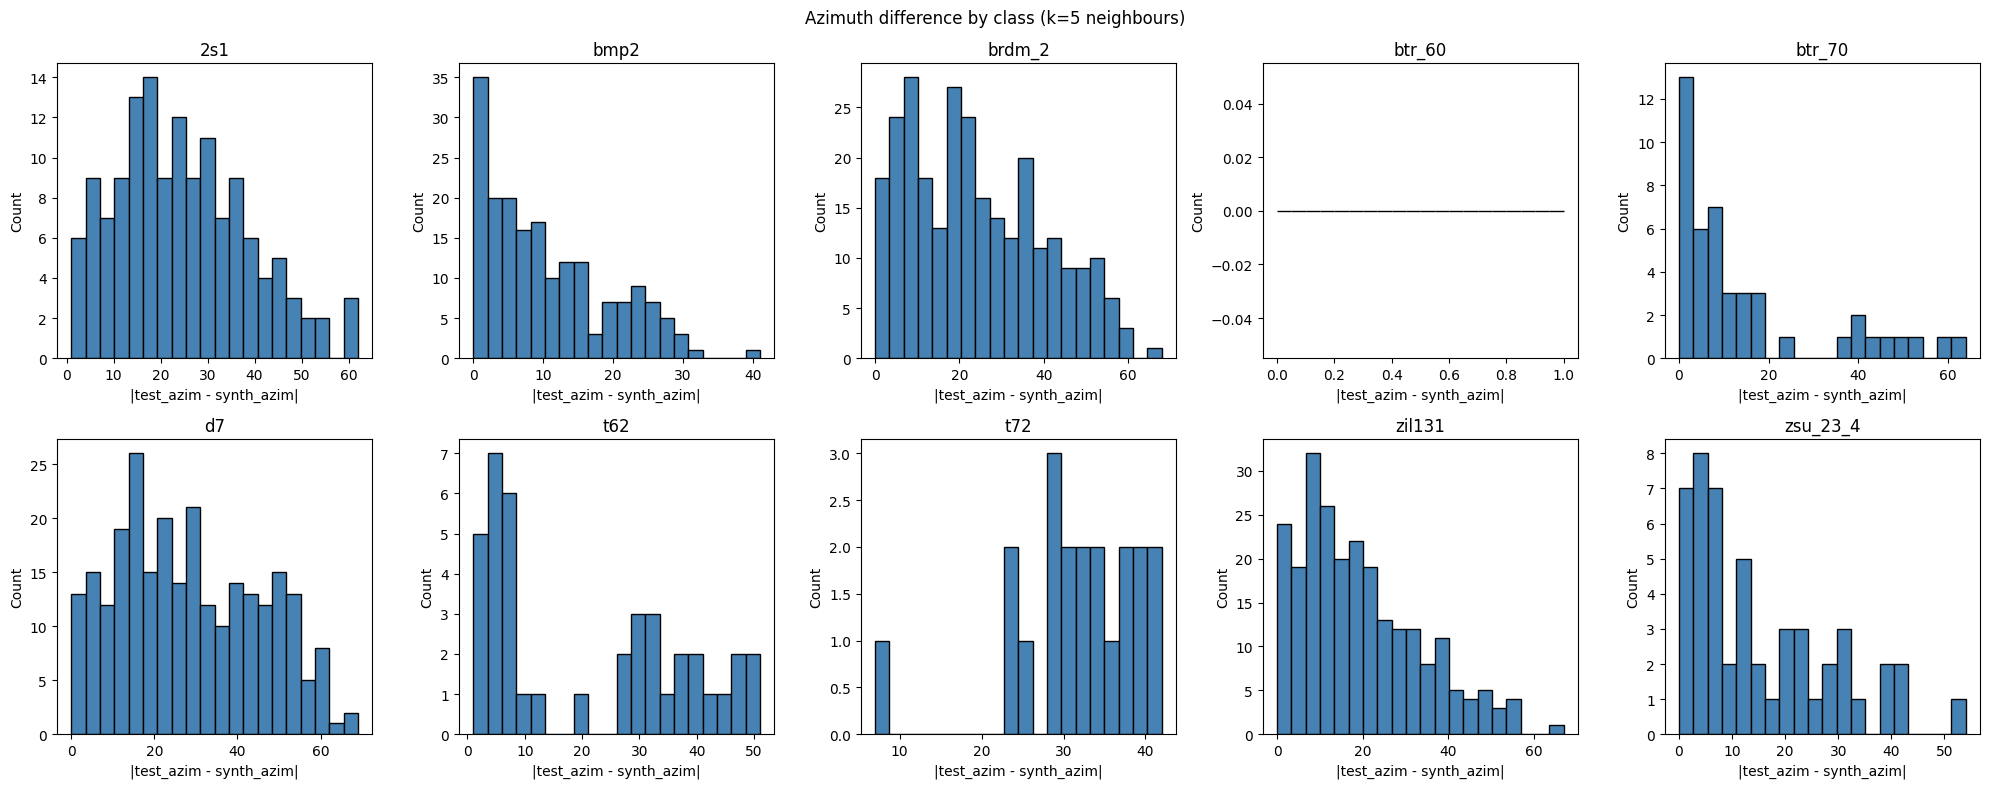

In [18]:
results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, meas_labels, meas_preds,
    train_plot_ds, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, meas_labels, meas_preds,
    train_plot_ds, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(meas_preds) == cp.asnumpy(meas_labels)
correct_classes = cp.asnumpy(meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(test_ds, azim_diffs, correct_classes)